## Aral Sea Model -  simulations


In [1]:
# setup imports
import sys
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import xarray as xr
import yaml

import importlib
import src.aral as aral
importlib.reload(aral)


#from src.paths import GRDC
from ewatercycle.observation.grdc import get_grdc_data


In [2]:
# load the project configuration
config_path = PROJECT_ROOT / "config_aral.yaml"
with config_path.open("r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

config_path, config["project"]["title"]

(PosixPath('/home/avandervee3/aral_sea_full_project/config_aral.yaml'),
 'Aral Sea Level Modelling')

In [3]:
# load the historical and future station output files
with config_path.open("r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

def resolve_project_path(config_path_value):
    return PROJECT_ROOT / config_path_value

historical_nc = resolve_project_path(config["aral_sea_experiment"]["final_station_historical"])
future_nc = resolve_project_path(config["aral_sea_experiment"]["final_station_future"])

historical_ds = xr.load_dataset(historical_nc)
future_ds = xr.load_dataset(future_nc)

historical_da = historical_ds["discharge"]
future_da = future_ds["discharge"]


In [4]:
historical_da.coords['experiment'].values
future_da.coords['experiment'].values

array(['run_id=r011__model=MIROC6__scenario=ssp245__type=bias_corrected__parameter_set=overall_calibrated__era=future',
       'run_id=r012__model=MPI-ESM1-2-HR__scenario=ssp245__type=bias_corrected__parameter_set=overall_calibrated__era=future',
       'run_id=r013__model=CanESM5__scenario=ssp245__type=bias_corrected__parameter_set=overall_calibrated__era=future',
       'run_id=r014__model=MPI-ESM1-2-HR__scenario=ssp126__type=bias_corrected__parameter_set=overall_calibrated__era=future',
       'run_id=r015__model=MPI-ESM1-2-HR__scenario=ssp370__type=bias_corrected__parameter_set=overall_calibrated__era=future',
       'run_id=r016__model=MPI-ESM1-2-HR__scenario=ssp585__type=bias_corrected__parameter_set=overall_calibrated__era=future',
       'run_id=r019__model=MRI-ESM2-0__scenario=ssp245__type=bias_corrected__parameter_set=overall_calibrated__era=future'],
      dtype='<U116')

In [5]:
def parse_experiment(exp_name):
    return dict(part.split("=") for part in exp_name.split("__"))

TYPE_LABELS = {
    "raw": "raw",
    "regridded": "uncorrected",
    "bias_corrected": "bias corrected",
}

def experiment_label(exp_name):
    p = parse_experiment(exp_name)
    model = p["model"]
    type_ = TYPE_LABELS.get(p["type"], p["type"])
    param = p["parameter_set"]
    
    if model == "era5":
        return f"ERA5 - {param}"
    else:
        return f"{model} - {type_}"

In [6]:
rivers = {}
for exp_name in future_da.experiment.values:
    rivers[exp_name] = {
        "Amu": aral.River(
            future_da.sel(experiment=exp_name, station="Chatly"),
            name=f"Amu - {experiment_label(exp_name)}"
        ),
        "Syr": aral.River(
            future_da.sel(experiment=exp_name, station="Kazalinsk"),
            name=f"Syr - {experiment_label(exp_name)}"
        )
    }

# era5_overall = 'run_id=r002__model=era5__scenario=era5__type=raw__parameter_set=overall_calibrated__era=historical'
# era5_amu_cal = 'run_id=r003__model=era5__scenario=era5__type=raw__parameter_set=amu_calibrated__era=historical'



# rivers["era5_river_specific_combined"] = {
#     "Amu": rivers[era5_amu_cal]["Amu"],
#     "Syr": rivers[era5_overall]["Syr"]
# }

In [7]:
aral_precip = xr.open_dataset("/home/avandervee3/aral_sea_full_project/aral_sea_model_forcing_cmip_future/MIROC6/MIROC6/ssp245/AralSea/2015-2099/work/diagnostic/script/CMIP6_MIROC6_day_ssp245_r1i1p1f1_pr_gn_2015-2099.nc")
aral_evap = xr.open_dataset("/home/avandervee3/aral_sea_full_project/aral_sea_model_forcing_cmip_future/MIROC6/MIROC6/ssp245/AralSea/2015-2099/work/diagnostic/script/Derived_Makkink_evspsblpot.nc")
ahv_file = resolve_project_path(config["aral_sea_experiment"]["bathymetry_path"])
initial_volume = 100

In [8]:
def run_sim(sim_name, rivers_dict):
    return aral.run_connected_aral_model(
        aral_meteo = aral_evap,
        aral_precip = aral_precip,
        rivers=[rivers_dict["Amu"], rivers_dict["Syr"]],
        ahv_csv=ahv_file,
        V0_km3=initial_volume,
        start_time="2015-01-01",
        end_time="2099-12-31",
        tqdm_position=1,
    )


importlib.reload(aral)
results = {}
labels = []
for sim, rivers_dict in rivers.items():
    results[sim] = run_sim(sim, rivers_dict)
    if sim == "era5_river_specific_combined":
        labels.append("ERA5 - river specific combined")
    else:
        labels.append(experiment_label(sim))


Simulating Aral Sea volume balance:   0%|          | 0/31045 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/31045 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/31045 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/31045 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/31045 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/31045 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/31045 [00:00<?, ?it/s]

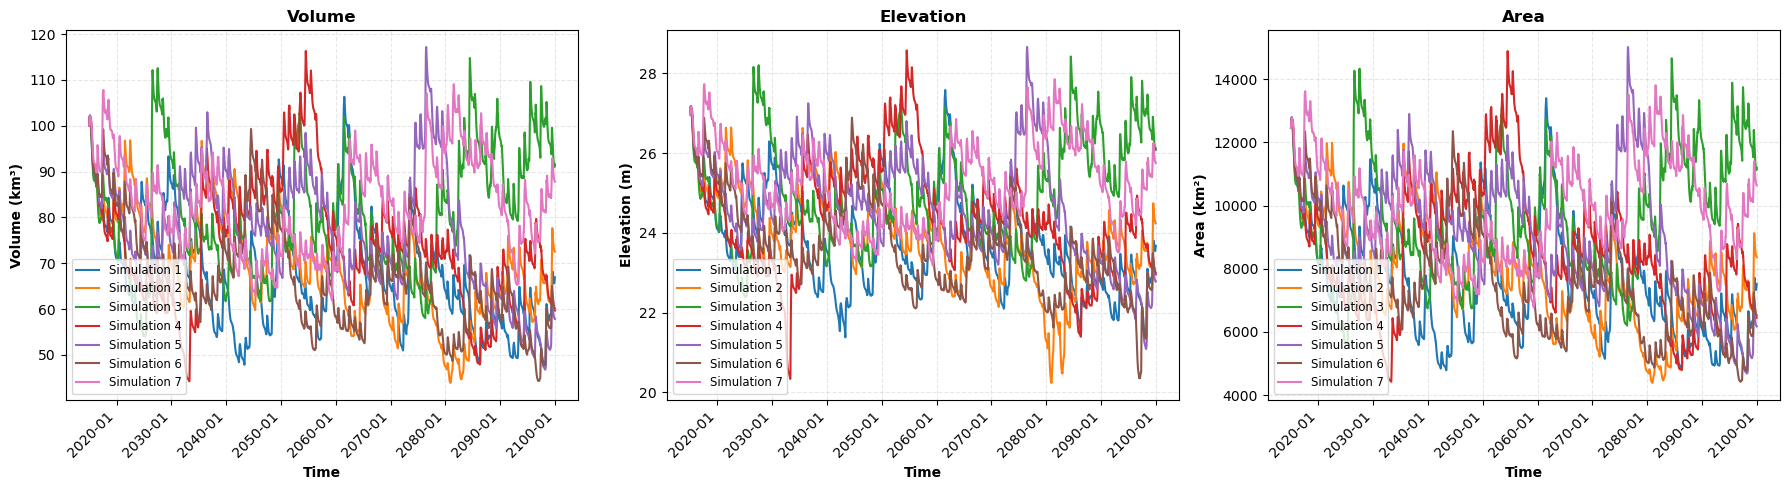

In [9]:
importlib.reload(aral)
# observation = aral.make_obs()
aral.plot_aral_results(
    list(results.values()),
)

Plot successfully saved to: aral_sea_elevation_CMIP6_futures.pdf


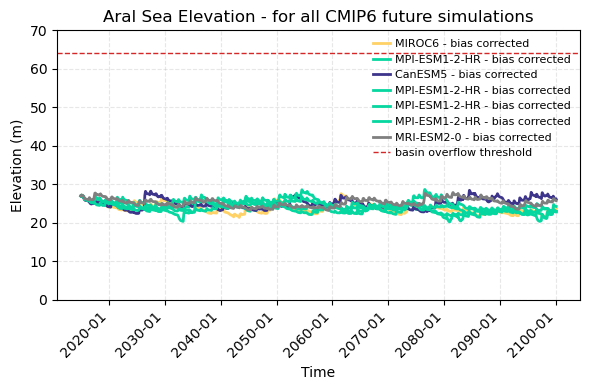

In [11]:
aral.plot_aral_elevation(
    list(results.values()),
    labels=labels,
    title = "Aral Sea Elevation - for all CMIP6 future simulations",
    save_path = "aral_sea_elevation_CMIP6_futures.pdf"

)

Plot successfully saved to: aral_sea_elevation_era5_calibrations.pdf


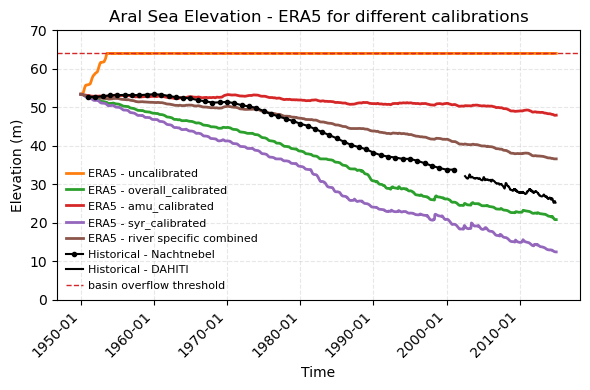

In [ ]:
selected_keys = list(results.keys())[:4] + [list(results.keys())[-1]]
selected_labels = labels[:4] + [labels[-1]]
importlib.reload(aral)
aral.plot_aral_elevation(
    [results[k] for k in selected_keys],
    labels=selected_labels,
    title = "Aral Sea Elevation - ERA5 for different calibrations",
    save_path = "aral_sea_elevation_era5_calibrations.pdf"
)

Plot successfully saved to: aral_sea_elevation_bias_corrected.pdf


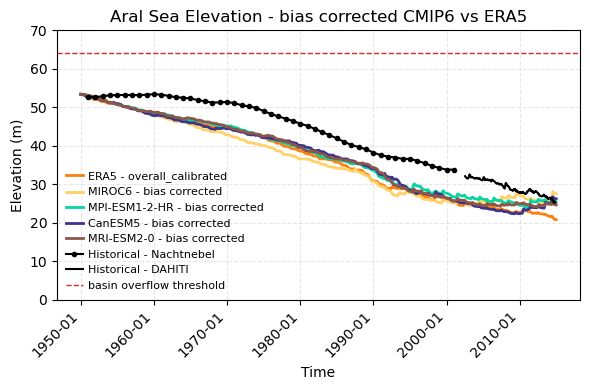

In [58]:
indices = [1,7, 8, 9, 11]
all_keys = list(results.keys())

selected_keys = [all_keys[i] for i in indices]
selected_labels = [labels[i] for i in indices]
importlib.reload(aral)
aral.plot_aral_elevation(
    [results[k] for k in selected_keys],
    labels=selected_labels,
    observations=observation,
    title = "Aral Sea Elevation - bias corrected CMIP6 vs ERA5",
    save_path = "aral_sea_elevation_bias_corrected.pdf"
)

Plot successfully saved to: aral_sea_elevation_uncorrected.pdf


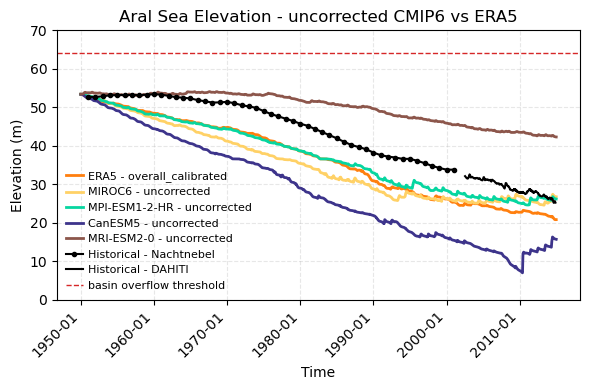

In [61]:
indices = [1, 4, 5, 6, 10]
all_keys = list(results.keys())

selected_keys = [all_keys[i] for i in indices]
selected_labels = [labels[i] for i in indices]
importlib.reload(aral)
aral.plot_aral_elevation(
    [results[k] for k in selected_keys],
    labels=selected_labels,
    observations=observation,
    title = "Aral Sea Elevation - uncorrected CMIP6 vs ERA5",
    save_path = "aral_sea_elevation_uncorrected.pdf"
)

In [60]:
selected_labels = [labels[i] for i in indices]
selected_labels

['ERA5 - overall_calibrated',
 'MIROC6 - uncorrected',
 'MPI-ESM1-2-HR - uncorrected',
 'CanESM5 - uncorrected',
 'MRI-ESM2-0 - uncorrected']

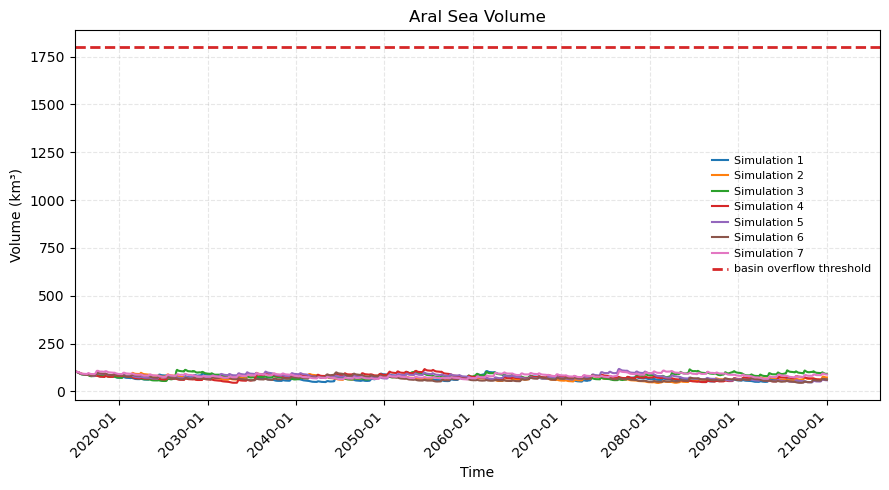

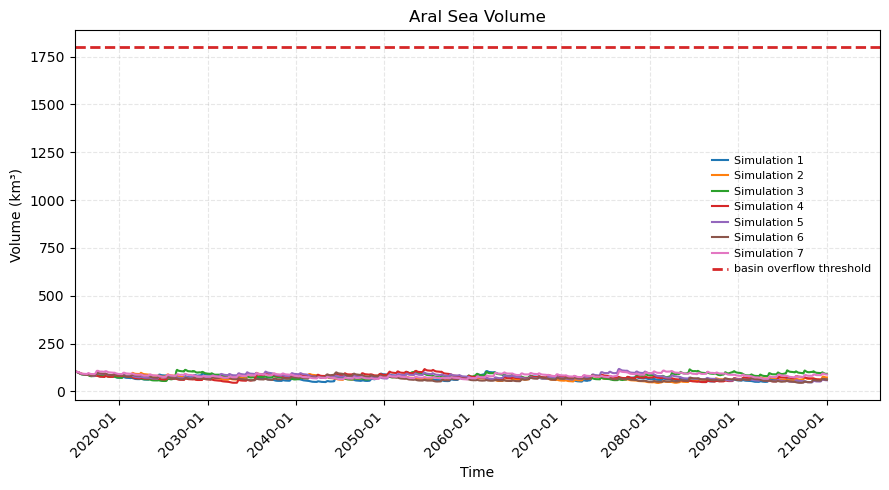

In [17]:

importlib.reload(aral)
aral.plot_aral_volume(
    list(results.values()),
    # title = "Aral Sea Elevation - all CMIP6 futures",
    # save_path = "aral_sea_elevation_CMIP6_futures.png"
)

In [62]:
df = list(results.values())[0]
print(df.dtypes)
print(df.head())

time             datetime64[ns]
volume_km3              float64
area_km2                float64
elevation_m             float64
Q_in_km3day             float64
evap_km3day             float64
precip_km3day           float64
dtype: object
                 time   volume_km3      area_km2  elevation_m  Q_in_km3day  \
0 1950-01-01 12:00:00  1100.000000           NaN          NaN          NaN   
1 1950-01-02 12:00:00  1100.053086  67947.027027    53.384095     0.082113   
2 1950-01-03 12:00:00  1100.106510  67951.044348    53.384884     0.081425   
3 1950-01-04 12:00:00  1100.155090  67955.087218    53.385678     0.084070   
4 1950-01-05 12:00:00  1100.194926  67958.763585    53.386400     0.088075   

   evap_km3day  precip_km3day  
0          NaN            NaN  
1     0.026289   1.877475e-06  
2     0.025262   2.416885e-07  
3     0.032752   1.424255e-06  
4     0.045500   1.848235e-07  


In [65]:
output_dir = Path("../output/simulations/historical")
output_dir.mkdir(parents=True, exist_ok=True)
output_file = output_dir / "historical_results.nc"

# Save
sim_names = [str(k) for k in results.keys()]
ds = xr.concat(
    [xr.Dataset.from_dataframe(df.set_index("time")) for df in results.values()],
    dim=pd.Index(sim_names, name="simulation")
)
ds.to_netcdf(output_file)

# Load
ds = xr.open_dataset(output_file)
sim_names = ds.simulation.values.tolist()
results = {}
labels = []
for sim_name in sim_names:
    df = ds.sel(simulation=sim_name).to_dataframe().reset_index()
    df["time"] = pd.to_datetime(df["time"])
    results[sim_name] = df
    if sim_name == "era5_river_specific_combined":
        labels.append("ERA5 - river specific combined")
    else:
        labels.append(experiment_label(sim_name))